# Pipeline huấn luyện **v1 RESIZE (LSTM 64→32)** + Export INT8 cho ESP32-S3

Kiến trúc CNN-LSTM thu nhỏ (LSTM 128→64 ⇒ 64→32, ~164k→~60k tham số).
Toàn bộ notebook chạy **Keras 2 (legacy)** để LSTM fuse được khi convert TFLite.

## 1. Kết nối Google Drive, cài tf-keras & giải nén Dataset

In [1]:
# === Kích hoạt Keras 2 (legacy) cho TOÀN BỘ notebook ===
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
!pip install -q tf-keras

import shutil

ZIP_PATH  = '/media/data3/users/hungvm/dataset/sisfall/archive.zip'
WORKSPACE = '/media/data3/users/hungvm/dataset/sisfall/workspace'

if not os.path.exists(WORKSPACE):
    os.makedirs(WORKSPACE)
    !unzip -q "{ZIP_PATH}" -d "{WORKSPACE}"
    print("Giải nén hoàn tất!")
else:
    print("Workspace đã tồn tại!")

Workspace đã tồn tại!


# 2. Tiền xử lý (Extract & Preprocess - Step 1)
Chuyển đổi gia tốc (g), góc quay (rad/s) và downsample 100Hz.


In [2]:
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

INPUT_DIR  = Path(WORKSPACE) / 'SisFall_dataset'
OUTPUT_DIR = Path(WORKSPACE) / 'SisFall_dataset_Processed'

target_har = {'D01', 'D02', 'D03', 'D04', 'D05', 'D07', 'D08', 'D11', 'D12', 'D13', 'D15', 'D17', 'D18', 'D19'}
ACCEL_SCALE = 32.0 / 8192.0
GYRO_SCALE = (4000.0 / 65536.0) * (np.pi / 180.0)

all_files = list(INPUT_DIR.rglob('*.txt'))
files_to_process = [f for f in all_files if f.name.startswith('F') or f.name[:3] in target_har]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for file_path in tqdm(files_to_process, desc="Preprocessing"):
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            
        data = []
        for line in lines:
            line = line.strip().rstrip(';')
            if not line: continue
            parts = line.split(',')
            if len(parts) >= 6:
                data.append([float(x) for x in parts[:6]])
                
        if not data: continue
        df = pd.DataFrame(data, columns=['ax', 'ay', 'az', 'gx', 'gy', 'gz'])
        
        df[['ax', 'ay', 'az']] *= ACCEL_SCALE
        df[['gx', 'gy', 'gz']] *= GYRO_SCALE
        df = df.iloc[::2, :].reset_index(drop=True)
        
        rel_path = file_path.relative_to(INPUT_DIR)
        out_file = OUTPUT_DIR / rel_path.parent / (file_path.stem + '.csv')
        out_file.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_file, index=False)
    except Exception as e:
        pass
print("Hoàn tất Step 1!")


Preprocessing:   0%|          | 0/3637 [00:00<?, ?it/s]

Hoàn tất Step 1!


# 3. Cắt Window (Windowing - Step 2) — bản chỉnh cho Trans/D18/D19

- **D18 (vấp khi đi)** & **D19 (nhảy nhẹ)**: chỉ lấy **1 cửa sổ Trans** tại đỉnh SVM cao nhất; phần đi bộ còn lại **bỏ hết** (không Walk, không Idle).
- **Trans augment ×3**: dịch trước/sau 20 mẫu — **chỉ cho subject TRAIN** (tránh thổi phồng Val/Test).
- D01/D02/D05→Walk, D03/D04→Run (sliding window); D07…D17→Trans(≤2 đỉnh)+Idle.

In [3]:
from scipy.signal import find_peaks

WINDOW_OUTPUT_DIR = Path(WORKSPACE) / 'SisFall_dataset_Windowed_new'

# Chỉ AUGMENT Trans cho các subject thuộc tập TRAIN -> tránh rò rỉ/thổi phồng Val/Test.
TRAIN_SUBJECTS = {f"SA{i:02d}" for i in range(1, 19)} | {f"SE{i:02d}" for i in range(1, 9)}
TRANS_AUG_SHIFTS = [-20, 0, 20]   # dịch trước/sau 20 mẫu -> x3 mẫu Trans

def extract_window(df, center, window_size=200):
    start, end = center - window_size // 2, center + window_size // 2
    if start < 0: start, end = 0, window_size
    if end > len(df): end, start = len(df), max(0, len(df) - window_size)
    return df.iloc[start:end]

def classify_idle(win_df):
    ax_m, ay_m, az_m = win_df['ax'].abs().mean(), win_df['ay'].abs().mean(), win_df['az'].abs().mean()
    return 'Idle_StandSit' if (ay_m > ax_m and ay_m > az_m) else 'Idle_Lie'

def save_trans(df, peak, out_dir, filename, subject_id, tag):
    # Lưu 1 cửa sổ Trans tại peak; augment x3 (dịch +-20) nếu subject thuộc TRAIN.
    shifts = TRANS_AUG_SHIFTS if subject_id in TRAIN_SUBJECTS else [0]
    n = 0
    for shift in shifts:
        win = extract_window(df, peak + shift)
        if len(win) == 200:
            win.to_csv(out_dir / f"{filename}_Trans_{tag}_s{shift:+d}.csv", index=False)
            n += 1
    return n

all_processed = list(OUTPUT_DIR.rglob('*.csv'))
trans_har    = {'D07', 'D08', 'D11', 'D12', 'D13', 'D15', 'D17'}  # ADL ngồi/đứng/nằm -> Trans + Idle
cont_har     = {'D01', 'D02', 'D03', 'D04', 'D05'}                # đi/chạy liên tục (KHÔNG còn D18/D19)
stumble_jump = {'D18', 'D19'}                                     # D18 vấp khi đi, D19 nhảy nhẹ

windows_generated = 0
for f in tqdm(all_processed, desc="Windowing"):
    df = pd.read_csv(f)
    if len(df) < 200: continue

    filename, prefix = f.stem, f.stem[:3]
    subject_id = filename.split('_')[1]
    out_dir = WINDOW_OUTPUT_DIR / f.parent.name
    out_dir.mkdir(parents=True, exist_ok=True)
    svm = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

    if filename.startswith('F'):
        # Fall: 5 cửa sổ quanh đỉnh va chạm
        peak_idx = int(svm.argmax())
        for w_idx, shift in enumerate([-60, -30, 0, 30, 60]):
            win = extract_window(df, peak_idx + shift)
            if len(win) == 200:
                win.to_csv(out_dir / f"{filename}_Fall_W{w_idx:03d}.csv", index=False)
                windows_generated += 1

    elif prefix in stumble_jump:
        # D18 (vấp khi đi) / D19 (nhảy nhẹ): CHỈ 1 cửa sổ Trans tại đỉnh SVM cao nhất.
        # Phần còn lại (đi bộ) BỎ HẾT: không lấy Walk, không lấy Idle (Walk đã quá nhiều).
        peak_idx = int(svm.argmax())
        windows_generated += save_trans(df, peak_idx, out_dir, filename, subject_id, 'P000')

    elif prefix in trans_har:
        # ADL chuyển động: lấy tối đa 2 đỉnh SVM cao nhất làm Trans (mỗi đỉnh augment x3 nếu train)
        peaks, props = find_peaks(svm, height=1.0, distance=200)
        if len(peaks) >= 2:
            selected_peaks = np.sort(peaks[np.argsort(props['peak_heights'])[-2:]])
        elif len(peaks) == 1:
            selected_peaks = peaks
        else:
            selected_peaks = [int(svm.argmax())]

        for i, peak in enumerate(selected_peaks):
            windows_generated += save_trans(df, int(peak), out_dir, filename, subject_id, f'W{i:03d}')

        # Idle: các đoạn cách xa MỌI đỉnh >= 80 mẫu (không augment)
        for start in range(0, len(df) - 200 + 1, 100):
            center = start + 100
            if all(abs(center - p) >= 80 for p in selected_peaks):
                win = df.iloc[start:start+200]
                win.to_csv(out_dir / f"{filename}_{classify_idle(win)}_W{start//100:03d}.csv", index=False)
                windows_generated += 1

    elif prefix in cont_har:
        # Đi/chạy liên tục: sliding window step=100
        for start in range(0, len(df) - 200 + 1, 100):
            win = df.iloc[start:start+200]
            label = "Walk" if prefix in {'D01', 'D02', 'D05'} else "Run"
            win.to_csv(out_dir / f"{filename}_{label}_W{start//100:03d}.csv", index=False)
            windows_generated += 1

print(f"Hoàn tất Windowing! Tổng số cửa sổ: {windows_generated}")

Windowing:   0%|          | 0/3637 [00:00<?, ?it/s]

Hoàn tất Windowing! Tổng số cửa sổ: 47506


# 4. ML Pipeline I/O (DataPreprocessor & OutputReporter)
Đây là 2 class cốt lõi chịu trách nhiệm tổ chức Dataloader, Caching, Split Subject và Report.


In [4]:
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import shutil

class DataPreprocessor:
    def __init__(self, data_dir, cache_dir, class_names):
        self.data_dir = Path(data_dir)
        self.cache_dir = Path(cache_dir)
        self.class_names = class_names
        
        self.TRAIN_SUBJECTS = {f"SA{i:02d}" for i in range(1, 19)} | {f"SE{i:02d}" for i in range(1, 9)}
        self.VAL_SUBJECTS = {f"SA{i:02d}" for i in range(19, 22)} | {f"SE{i:02d}" for i in range(9, 12)}
        self.TEST_SUBJECTS = {f"SA{i:02d}" for i in range(22, 24)} | {f"SE{i:02d}" for i in range(12, 16)}

    def parse_filename_info(self, filename):
        if '_Trans_' in filename: return 'Trans'
        if '_StandSit_' in filename or '_Lie_' in filename: return 'Idle'
        prefix = filename[:3]
        if prefix in ['D01', 'D02', 'D05', 'D06']: return 'Walk'
        if prefix in ['D03', 'D04']: return 'Run'
        if prefix.startswith('F'): return 'Fall'
        return None

    def load_single_csv(self, file_path):
        try:
            filename = file_path.stem
            subject_id = filename.split('_')[1]
            label_str = self.parse_filename_info(filename)
            if label_str is None: return None
            label = self.class_names.index(label_str)
            df = pd.read_csv(file_path)
            if len(df) != 200: return None
            return df.to_numpy(), label, subject_id
        except: return None

    def load_or_create_dataset(self):
        self.cache_dir.mkdir(exist_ok=True, parents=True)
        train_x, train_y = self.cache_dir/'X_train.npy', self.cache_dir/'y_train.npy'
        val_x, val_y = self.cache_dir/'X_val.npy', self.cache_dir/'y_val.npy'
        test_x, test_y = self.cache_dir/'X_test.npy', self.cache_dir/'y_test.npy'
        
        if all(p.exists() for p in [train_x, train_y, val_x, val_y, test_x, test_y]):
            print("[*] Load data từ Cache...")
            return (np.load(train_x), np.load(train_y), np.load(val_x), np.load(val_y), np.load(test_x), np.load(test_y))

        print(f"[*] Đang đọc file CSV từ {self.data_dir}...")
        all_files = list(self.data_dir.rglob('*.csv'))
        
        if len(all_files) == 0:
            raise FileNotFoundError(f"LỖI: Không tìm thấy file CSV nào trong {self.data_dir}. Vui lòng chạy lại Bước 2 (Windowing)!")
            
        X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
        
        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in tqdm(executor.map(self.load_single_csv, all_files), total=len(all_files)):
                if res is None: continue
                data, label, sub = res
                if sub in self.TRAIN_SUBJECTS: X_train.append(data); y_train.append(label)
                elif sub in self.VAL_SUBJECTS: X_val.append(data); y_val.append(label)
                elif sub in self.TEST_SUBJECTS: X_test.append(data); y_test.append(label)
                    
        X_train, y_train = np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int32)
        X_val, y_val = np.array(X_val, dtype=np.float32), np.array(y_val, dtype=np.int32)
        X_test, y_test = np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.int32)
        
        np.save(train_x, X_train); np.save(train_y, y_train)
        np.save(val_x, X_val); np.save(val_y, y_val)
        np.save(test_x, X_test); np.save(test_y, y_test)
        
        return X_train, y_train, X_val, y_val, X_test, y_test

    def apply_preprocessing(self, X_train, X_val, X_test):
        # Sửa lỗi Index Error: Chỉ cắt mảng nếu mảng thực sự có chứa dữ liệu (3 chiều)
        for X in [X_train, X_val, X_test]:
            if X.ndim == 3 and X.shape[0] > 0:
                X[:, :, 0:3] = np.clip(X[:, :, 0:3], -8.0, 8.0) / 8.0
                X[:, :, 3:6] = X[:, :, 3:6] / 2000.0
        return X_train, X_val, X_test

    def get_balanced_class_weights(self, y_train, class_weight_modifiers=None):
        if len(y_train) == 0: return {}
        vals = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        weights = dict(zip(np.unique(y_train), vals))
        if class_weight_modifiers:
            for cls_name, mod in class_weight_modifiers.items():
                if cls_name in self.class_names:
                    weights[self.class_names.index(cls_name)] *= mod
        return weights

class OutputReporter:
    def __init__(self, out_dir, class_names):
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(exist_ok=True, parents=True)
        self.class_names = class_names

    def plot_training_history(self, history, version="v_colab"):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.legend(); plt.title('Accuracy')
        plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.legend(); plt.title('Loss')
        plt.tight_layout(); plt.savefig(self.out_dir / f'history_{version}.png'); plt.show()

    def evaluate_and_report(self, model, X_test, y_test, version="v_colab", fall_threshold=0.25):
        if len(X_test) == 0: return
        fall_idx = self.class_names.index('Fall')
        y_pred_probs = model.predict(X_test, batch_size=256)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_pred[y_pred_probs[:, fall_idx] >= fall_threshold] = fall_idx
        
        report_str = "\n" + "="*50 + "\n"
        report_str += f"BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - {version} (Threshold {fall_threshold})\n"
        report_str += "="*50 + "\n"
        
        cls_report = classification_report(y_test, y_pred, target_names=self.class_names, digits=4)
        report_str += cls_report + "\n"
        print(report_str)
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8,6))
        plt.imshow(cm, cmap=plt.cm.Blues); plt.colorbar()
        plt.xticks(np.arange(len(self.class_names)), self.class_names, rotation=45)
        plt.yticks(np.arange(len(self.class_names)), self.class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i,j],'d'), ha="center", color="white" if cm[i,j] > cm.max()/2. else "black")
        plt.ylabel('Nhãn Thực Tế')
        plt.xlabel('Nhãn Dự Đoán')
        plt.tight_layout()
        plt.savefig(self.out_dir / f'confusion_matrix_{version}.png')
        plt.show()
        
        true_falls = np.sum(y_test == fall_idx)
        detected_falls = cm[fall_idx, fall_idx]
        recall_fall = (detected_falls / true_falls) * 100 if true_falls > 0 else 0
        
        eval_str = "\n" + "="*50 + "\n"
        eval_str += "KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):\n"
        eval_str += f"  - Số ca ngã thực tế: {true_falls}\n"
        eval_str += f"  - Số ca ngã phát hiện đúng: {detected_falls}\n"
        eval_str += f"  - TỶ LỆ RECALL TÉ NGÃ: {recall_fall:.2f}%\n"
        eval_str += "="*50 + "\n"
        
        print(eval_str)
        report_str += eval_str
        
        with open(self.out_dir / f'report_{version}.txt', 'w', encoding='utf-8') as rf:
            rf.write(report_str)
        print(f"[*] Đã lưu báo cáo tại {self.out_dir / f'report_{version}.txt'}")


I0000 00:00:1781755874.136833  268329 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 5. Kiến trúc Model — RESIZE (LSTM 64→32)

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dropout, Dense
from tensorflow.keras.models import Model

def build_model(input_shape=(200, 6), n_classes=5):
    # Kiến trúc v1 RESIZE: LSTM 128->64 đã thu nhỏ còn 64->32 (giảm ~2.7x tham số ~164k -> ~60k)
    inputs = Input(shape=input_shape)

    # CNN block (giữ nguyên)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    # LSTM block (THU NHỎ: 64 -> 32)
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(32)(x)
    x = Dropout(0.4)(x)

    # Classification head
    x = Dense(32, activation='relu')(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

# 6. Huấn luyện + Đánh giá

[*] Đang đọc file CSV từ /media/data3/users/hungvm/dataset/sisfall/workspace/SisFall_dataset_Windowed_new...


  0%|          | 0/47506 [00:00<?, ?it/s]

Phân bố nhãn train: {'Walk': 8427, 'Run': 5217, 'Idle': 8365, 'Trans': 5706, 'Fall': 7125}


I0000 00:00:1781755927.402128  268329 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6671 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 6)]          0         
                                                                 
 conv1d (Conv1D)             (None, 200, 64)           1216      
                                                                 
 conv1d_1 (Conv1D)           (None, 200, 64)           12352     
                                                                 
 max_pooling1d (MaxPooling1  (None, 100, 64)           0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 100, 64)           0         
                                                                 
 lstm (LSTM)                 (None, 100, 64)           33024     
                                                             

I0000 00:00:1781755933.530871  269007 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781755935.320905  269006 service.cc:153] XLA service 0x7fbbc006bd20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781755935.320927  269006 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781755935.443769  269006 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781755935.850973  269006 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


545/545 [==============================] - ETA: 0s - loss: 1.3023 - accuracy: 0.5579
Epoch 1: val_loss improved from inf to 1.00565, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_resize_64_32/best_model_resize_64_32.keras
545/545 [==============================] - 15s 16ms/step - loss: 1.3023 - accuracy: 0.5579 - val_loss: 1.0057 - val_accuracy: 0.6726 - lr: 0.0010
Epoch 2/100
543/545 [============================>.] - ETA: 0s - loss: 1.1349 - accuracy: 0.6778
Epoch 2: val_loss improved from 1.00565 to 0.79830, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_resize_64_32/best_model_resize_64_32.keras
545/545 [==============================] - 8s 14ms/step - loss: 1.1343 - accuracy: 0.6781 - val_loss: 0.7983 - val_accuracy: 0.8385 - lr: 0.0010
Epoch 3/100
545/545 [==============================] - ETA: 0s - loss: 0.9258 - accuracy: 0.8230
Epoch 3: val_loss improved from 0.79830 to 0.79428, saving model to /media/data3/users/hungvm/

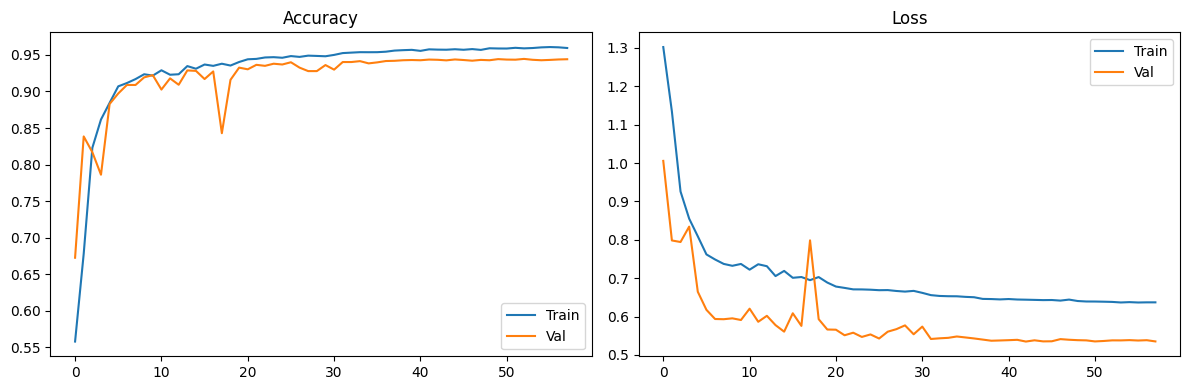

24/24 [==============================] - 1s 6ms/step

BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - resize_64_32 (Threshold 0.25)
              precision    recall  f1-score   support

        Walk     0.9699    0.9140    0.9411      1906
         Run     0.9741    0.9705    0.9723      1085
        Idle     0.9107    0.9364    0.9234      1982
       Trans     0.7404    0.8902    0.8084       410
        Fall     0.9986    0.9653    0.9817       750

    accuracy                         0.9359      6133
   macro avg     0.9187    0.9353    0.9254      6133
weighted avg     0.9397    0.9359    0.9370      6133




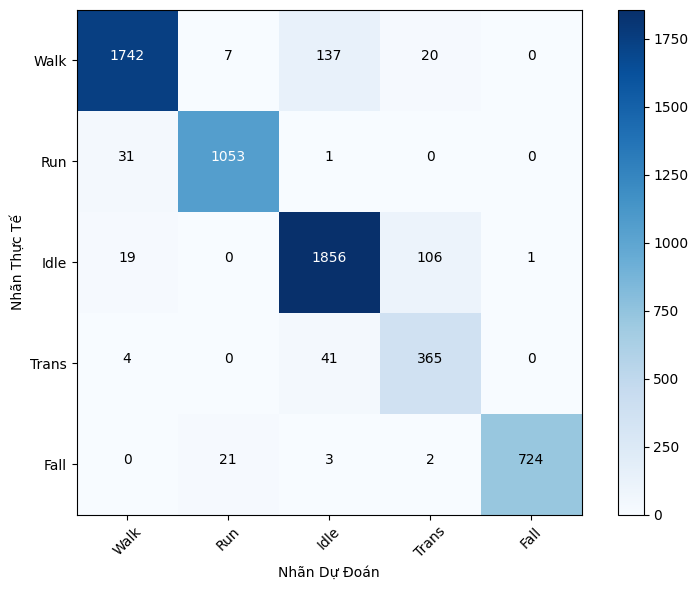


KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):
  - Số ca ngã thực tế: 750
  - Số ca ngã phát hiện đúng: 724
  - TỶ LỆ RECALL TÉ NGÃ: 96.53%

[*] Đã lưu báo cáo tại /media/data3/users/hungvm/dataset/sisfall/workspace/output_resize_64_32/report_resize_64_32.txt


In [6]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

class FallDetectionTrainerResize(DataPreprocessor, OutputReporter):
    def __init__(self):
        data_dir  = f'{WORKSPACE}/SisFall_dataset_Windowed_new'
        cache_dir = f'{WORKSPACE}/cache_resize_64_32'
        out_dir   = f'{WORKSPACE}/output_resize_64_32'
        class_names = ['Walk', 'Run', 'Idle', 'Trans', 'Fall']
        DataPreprocessor.__init__(self, data_dir, cache_dir, class_names)
        OutputReporter.__init__(self, out_dir, class_names)
        self.version = "resize_64_32"

trainer = FallDetectionTrainerResize()
checkpoint_path = Path(trainer.out_dir) / f'best_model_{trainer.version}.keras'

# 1. Nạp + tiền xử lý
X_train, y_train, X_val, y_val, X_test, y_test = trainer.load_or_create_dataset()
X_train, X_val, X_test = trainer.apply_preprocessing(X_train, X_val, X_test)
print("Phân bố nhãn train:", {trainer.class_names[k]: int((y_train==k).sum()) for k in range(5)})

# 2. Class weights (đẩy Fall x3)
weight_modifiers = {'Fall': 3.0, 'Trans': 1.0, 'Idle': 1.0}
class_weights = trainer.get_balanced_class_weights(y_train, weight_modifiers)

# 3. One-hot
y_train_oh = to_categorical(y_train, num_classes=5)
y_val_oh = to_categorical(y_val, num_classes=5)

# 4. Build model RESIZE
model = build_model(input_shape=(200, 6), n_classes=5)
model.summary()

# 5. Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=1),
]

# 6. Train
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100, batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)

# 7. Đánh giá
trainer.plot_training_history(history, version=trainer.version)
trainer.evaluate_and_report(model, X_test, y_test, version=trainer.version, fall_threshold=0.25)

# 7. Export INT8 TFLite → `model_data_v1_resize.cc/.h`

In [7]:
# === Export INT8 TFLite + sinh model_data .cc/.h cho ESP32-S3 / TFLM ===
# Notebook đang chạy Keras 2 (legacy) nên LSTM fuse thẳng thành UNIDIRECTIONAL_SEQUENCE_LSTM.
import numpy as np

out_dir = Path(trainer.out_dir)

# Representative dataset: X_train ĐÃ được scale ở apply_preprocessing -> dùng trực tiếp.
np.random.seed(42)
rep_idx = np.random.choice(len(X_train), size=min(300, len(X_train)), replace=False)
def representative_data_gen():
    for i in rep_idx:
        yield [X_train[i:i+1].astype(np.float32)]

# Clone sang batch cố định = 1 để chắc chắn LSTM fuse khi convert.
static_in = tf.keras.Input(batch_shape=(1, 200, 6), dtype='float32')
static_model = tf.keras.models.clone_model(model, input_tensors=static_in)
static_model.set_weights(model.get_weights())

converter = tf.lite.TFLiteConverter.from_keras_model(static_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

tflite_path = out_dir / 'model_resize_64_32_int8.tflite'
tflite_path.write_bytes(tflite_model)
print(f"[*] Saved {tflite_path}  ({len(tflite_model)} bytes)")

# Kiểm tra IO + op (xác nhận LSTM đã fuse, KHÔNG có WHILE)
it = tf.lite.Interpreter(model_content=tflite_model); it.allocate_tensors()
print("[*] Input :", it.get_input_details()[0]['shape'], it.get_input_details()[0]['dtype'])
print("[*] Output:", it.get_output_details()[0]['shape'], it.get_output_details()[0]['dtype'])
print("[*] Ops   :", sorted({d['op_name'] for d in it._get_ops_details()}))

# Sinh C array
hexs = [f'0x{b:02x}' for b in tflite_model]
body = ''
for i, h in enumerate(hexs):
    body += h + ', '
    if (i + 1) % 12 == 0:
        body += '\n  '

cc = (
    '#include "model_data.h"\n\n'
    '// CNN-LSTM v1 RESIZE (LSTM 64->32) INT8 Quantized - 5 nhan: Walk,Run,Idle,Trans,Fall\n'
    '// Input: (200,6) INT8 | Output: (5) INT8\n'
    'const unsigned char g_model_data[] = {\n  '
    + body.strip(', ') +
    '\n};\n\n'
    f'const unsigned int g_model_data_len = {len(tflite_model)};\n'
)
(out_dir / 'model_data_v1_resize.cc').write_text(cc, encoding='utf-8')

h_lines = [
    '#ifndef MODEL_DATA_H_', '#define MODEL_DATA_H_', '',
    '#ifdef __cplusplus', 'extern "C" {', '#endif', '',
    'extern const unsigned char g_model_data[];',
    'extern const unsigned int g_model_data_len;', '',
    '#ifdef __cplusplus', '}', '#endif', '',
    '#endif  // MODEL_DATA_H_', ''
]
(out_dir / 'model_data_v1_resize.h').write_text("\n".join(h_lines), encoding='utf-8')
print(f"[*] Đã sinh model_data_v1_resize.cc / .h ({len(tflite_model)} bytes)")
print("[*] Op resolver firmware cần đăng ký đúng theo dòng '[*] Ops :' ở trên.")

INFO:tensorflow:Assets written to: /tmp/tmp4jak68h4/assets


INFO:tensorflow:Assets written to: /tmp/tmp4jak68h4/assets
/media/data3/users/hungvm/anaconda3/envs/har_fall/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781756402.298788  268329 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781756402.298807  268329 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781756402.299064  268329 reader.cc:83] Reading SavedModel from: /tmp/tmp4jak68h4
I0000 00:00:1781756402.313211  268329 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781756402.313232  268329 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp4jak68h4
I0000 00:00:1781756402.375592  268329 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1781756402.392459  268329 loader.cc:236] Restoring SavedModel bundle.
I0000 

[*] Saved /media/data3/users/hungvm/dataset/sisfall/workspace/output_resize_64_32/model_resize_64_32_int8.tflite  (75464 bytes)
[*] Input : [  1 200   6] <class 'numpy.int8'>
[*] Output: [1 5] <class 'numpy.int8'>
[*] Ops   : ['CONV_2D', 'DELEGATE', 'FULLY_CONNECTED', 'MAX_POOL_2D', 'RESHAPE', 'SOFTMAX', 'STRIDED_SLICE', 'UNIDIRECTIONAL_SEQUENCE_LSTM']
[*] Đã sinh model_data_v1_resize.cc / .h (75464 bytes)
[*] Op resolver firmware cần đăng ký đúng theo dòng '[*] Ops :' ở trên.
